Initial Dataset Preview:
   Home ID Appliance Type  Energy Consumption (kWh)   Time        Date  \
0       94         Fridge                      0.20  21:12  2023-12-02   
1      435           Oven                      0.23  20:11  2023-08-06   
2      466     Dishwasher                      0.32  06:39  2023-11-21   
3      496         Heater                      3.92  21:56  2023-01-21   
4      137      Microwave                      0.44  04:31  2023-08-26   

   Outdoor Temperature (°C)  Season  Household Size  
0                      -1.0    Fall               2  
1                      31.1  Summer               5  
2                      21.3    Fall               3  
3                      -4.2  Winter               1  
4                      34.5  Summer               5  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------               

/tmp/ipython-input-3629394763.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col])
/tmp/ipython-input-3629394763.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[col])



Detected datetime column: Time


/tmp/ipython-input-3629394763.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[datetime_col] = pd.to_datetime(df[datetime_col])


Detected energy column: Energy Consumption (kWh)

Processed Dataset Preview:
                     Home ID    Appliance Type  Energy Consumption (kWh)  \
Time                                                                       
2026-02-09 03:42:00       59            Lights                      1.02   
2026-02-09 02:57:00      419              Oven                      0.65   
2026-02-09 16:04:00      466            Heater                      2.03   
2026-02-09 08:40:00      281              Oven                      0.28   
2026-02-09 10:06:00      257  Air Conditioning                      4.84   

                           Date  Outdoor Temperature (°C)  Season  \
Time                                                                
2026-02-09 03:42:00  2023-12-22                       1.1    Fall   
2026-02-09 02:57:00  2023-01-12                       5.3  Winter   
2026-02-09 16:04:00  2023-06-05                      15.3  Spring   
2026-02-09 08:40:00  2023-03-25              

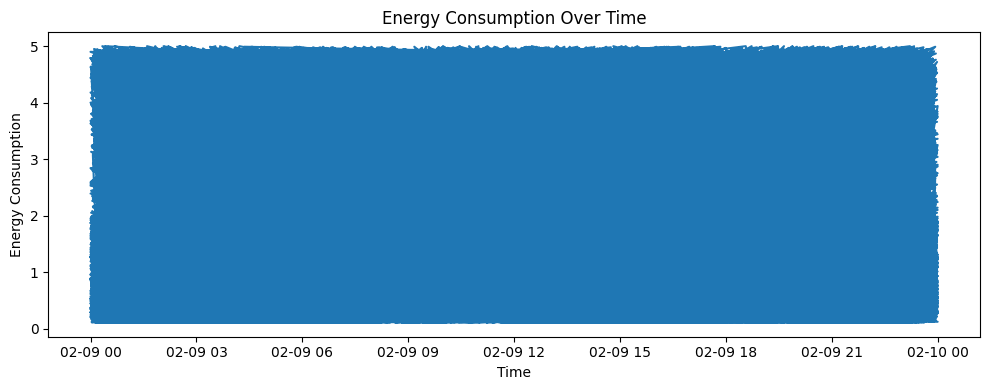


✅ Data preprocessing and feature engineering completed successfully.
Baseline Linear Regression Results
MAE : 0.8831288503225407
RMSE: 1.1571991453012114


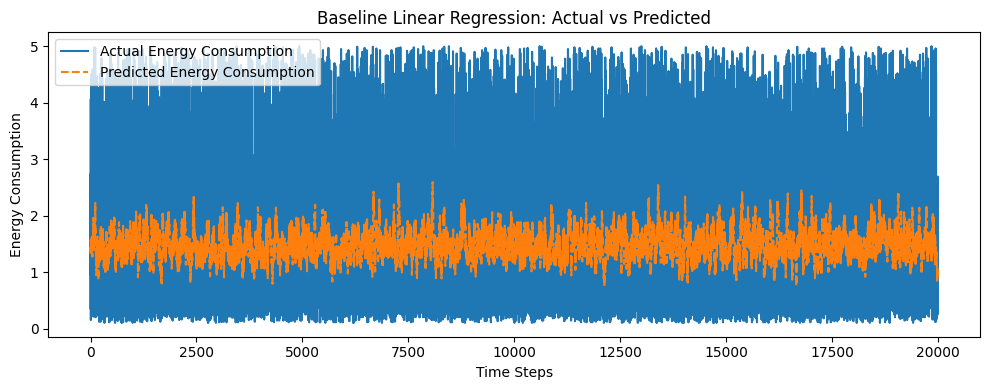

In [ ]:
# ============================================
# SMART ENERGY CONSUMPTION ANALYSIS
# DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("smart_home_energy_consumption_large.csv")

print("Initial Dataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# 2. Automatically detect datetime column
datetime_col = None
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            pd.to_datetime(df[col])
            datetime_col = col
            break
        except:
            pass

if datetime_col is None:
    raise ValueError("No datetime column found in dataset")

print(f"\nDetected datetime column: {datetime_col}")

# 3. Convert detected column to datetime & set index
df[datetime_col] = pd.to_datetime(df[datetime_col])
df = df.set_index(datetime_col)

# 4. Create time-based features
df['hour'] = df.index.hour
df['day'] = df.index.day
df['weekday'] = df.index.weekday
df['month'] = df.index.month

# 5. Identify energy consumption column automatically
energy_col = None
for col in df.columns:
    if 'energy' in col.lower():
        energy_col = col
        break

if energy_col is None:
    raise ValueError("Energy consumption column not found")

print(f"Detected energy column: {energy_col}")

# 6. Create lag features
df['lag_1'] = df[energy_col].shift(1)
df['lag_24'] = df[energy_col].shift(24)

# 7. Create rolling mean feature
df['rolling_mean_24'] = df[energy_col].rolling(window=24).mean()

# 8. Drop missing values
df = df.dropna()

# 9. Final dataset check
print("\nProcessed Dataset Preview:")
print(df.head())

print("\nProcessed Dataset Info:")
print(df.info())

# 10. Visualization
plt.figure(figsize=(10, 4))
plt.plot(df[energy_col])
plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.tight_layout()
plt.show()

# 11. Save processed dataset
df.to_csv("processed_energy_data.csv")

print("\n✅ Data preprocessing and feature engineering completed successfully.")
# ============================================
# BASELINE LINEAR REGRESSION MODEL (FIXED)
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify energy consumption column
energy_col = [col for col in df.columns if 'energy' in col.lower()][0]

# 2. Remove non-numeric (categorical) columns
X = df.drop(columns=[energy_col])
X = X.select_dtypes(include=[np.number])  # KEEP ONLY NUMERIC FEATURES

y = df[energy_col]

# 3. Train-test split (NO SHUFFLE for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 4. Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make predictions
y_pred = lr_model.predict(X_test)

# 6. Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression Results")
print("MAE :", mae)
print("RMSE:", rmse)

# 7. Plot Actual vs Predicted values
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label="Actual Energy Consumption")
plt.plot(y_pred, label="Predicted Energy Consumption", linestyle="--")
plt.title("Baseline Linear Regression: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Energy Consumption")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# LSTM STEP 5: SCALING ENERGY DATA
# ============================================

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Identify energy consumption column
energy_col = [col for col in df.columns if 'energy' in col.lower()][0]

# 2. Initialize MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 3. Scale ONLY the energy column
energy_values = df[[energy_col]].values
energy_scaled = scaler.fit_transform(energy_values)

# 4. Check scaled values
print("Original energy values (first 5):")
print(energy_values[:5])

print("\nScaled energy values (first 5):")
print(energy_scaled[:5])


Original energy values (first 5):
[[1.02]
 [0.65]
 [2.03]
 [0.28]
 [4.84]]

Scaled energy values (first 5):
[[0.1877551 ]
 [0.1122449 ]
 [0.39387755]
 [0.03673469]
 [0.96734694]]


In [ ]:
# ============================================
# LSTM STEP 6: CREATE TIME SERIES SEQUENCES
# ============================================

import numpy as np

# 1. Define number of time steps
TIME_STEPS = 24

# 2. Function to create sequences
def create_sequences(data, time_steps):
    X = []
    y = []
    for i in range(time_steps, len(data)):
        X.append(data[i - time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# 3. Create input-output sequences
X_lstm, y_lstm = create_sequences(energy_scaled, TIME_STEPS)

# 4. Check shapes
print("Input sequence shape (X):", X_lstm.shape)
print("Output shape (y):", y_lstm.shape)

# 5. Preview one sequence
print("\nSample input sequence (first 24 values):")
print(X_lstm[0])

print("\nCorresponding output value:")
print(y_lstm[0])


Input sequence shape (X): (99952, 24)
Output shape (y): (99952,)

Sample input sequence (first 24 values):
[0.1877551  0.1122449  0.39387755 0.03673469 0.96734694 0.05714286
 0.21836735 0.04081633 0.25714286 0.29591837 0.1122449  0.0755102
 0.29183673 0.12857143 0.56734694 0.16938776 0.3122449  0.14081633
 0.18571429 0.49795918 0.25102041 0.3122449  0.05714286 0.36326531]

Corresponding output value:
0.2530612244897959


In [ ]:
# ============================================
# LSTM STEP 7: TRAIN-TEST SPLIT & RESHAPING
# ============================================

# 1. Define train-test split index (80% training)
split_index = int(len(X_lstm) * 0.8)

# 2. Split data (NO SHUFFLE)
X_train = X_lstm[:split_index]
X_test = X_lstm[split_index:]

y_train = y_lstm[:split_index]
y_test = y_lstm[split_index:]

# 3. Reshape input data for LSTM
# LSTM expects 3D input: (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# 4. Check final shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (79961, 24, 1)
X_test shape : (19991, 24, 1)
y_train shape: (79961,)
y_test shape : (19991,)


In [ ]:
# ============================================
# LSTM STEP 8: BUILDING THE MODEL ARCHITECTURE
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Initialize the LSTM model
model = Sequential()

# 2. First LSTM layer (returns full sequence)
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

# 3. Dropout layer to prevent overfitting
model.add(Dropout(0.2))

# 4. Second LSTM layer
model.add(LSTM(units=32))

# 5. Another Dropout layer
model.add(Dropout(0.2))

# 6. Output layer (predict next energy value)
model.add(Dense(1))

# 7. Display model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# LSTM STEP 9: COMPILING & TRAINING THE MODEL
# ============================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

# 2. Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 3. Train the LSTM model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 68s 29ms/step - loss: 0.0601 - val_loss: 0.0583
Epoch 2/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - loss: 0.0579 - val_loss: 0.0584
Epoch 3/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - loss: 0.0585 - val_loss: 0.0586
Epoch 4/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - loss: 0.0591 - val_loss: 0.0584
Epoch 5/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - loss: 0.0582 - val_loss: 0.0583
Epoch 6/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - loss: 0.0581 - val_loss: 0.0584
Epoch 7/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 59s 26ms/step - loss: 0.0583 - val_loss: 0.0584
Epoch 8/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - loss: 0.0579 - val_loss: 0.0583
Epoch 9/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - loss: 0.0582 - val_loss: 0.0584
Epoch 10/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 81s 25ms/step - loss: 0.0580 - val_loss: 0.0584
Epoch 11/30
2249/2249 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - loss: 0.0583 - val_loss: 0.0583
Epoch 12